# Tutorial : Quality Control Analysis of Merged Chromatin Traces

Before filtering or downstream analysis, assess your data quality through comprehensive statistical analysis.

`trace_analyzer` computes:
- **Trace Statistics**: Distribution of barcode counts per trace
- **Barcode Detection**: How reliably each barcode is detected (bootstrap analysis)
- **Neighbor Distances**: Spacing between consecutive barcodes (ΔX, ΔY, ΔZ)
- **Barcode Frequencies**: How often individual barcodes appear
- **Spatial KDE Projections**: Density heatmaps showing where spots are located in X, Y, Z

These metrics guide filtering decisions in Tutorial 3.

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

# Data path from Tutorial 1
data_path = "/mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2"
dest_path = f"{data_path}/output"

# Input file from Boettiger
input_trace = f"{dest_path}/merged_traces.ecsv"

print(f"Input file: {input_trace}")
print(f"Output folder: {dest_path}")

Input file: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv
Output folder: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output


## Step 1: Run Quality Control Analysis

In [3]:
# Run trace_analyzer for detailed quality metrics
!trace_analyzer --input {input_trace} 

------- Running trace_analyzer.py --------
Analyze chromatin trace files.


1 trace files to process= /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv
> Analyzing traces for /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv
$ Number of spots in trace file: 94893
$ Calculating overall barcode detection across 1792 traces...
$ Exporting barcode detection plot to: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces_barcode_detection.png
$ Saved neighbor distances plot: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces_first_neighbor_distances.png
$ Mean distances between neighboring barcodes: X=0.000, Y=0.000, Z=0.000
$ Calculating barcode stats...
$ Exporting relative ba

## Step 2: Barcode Detection Efficiency

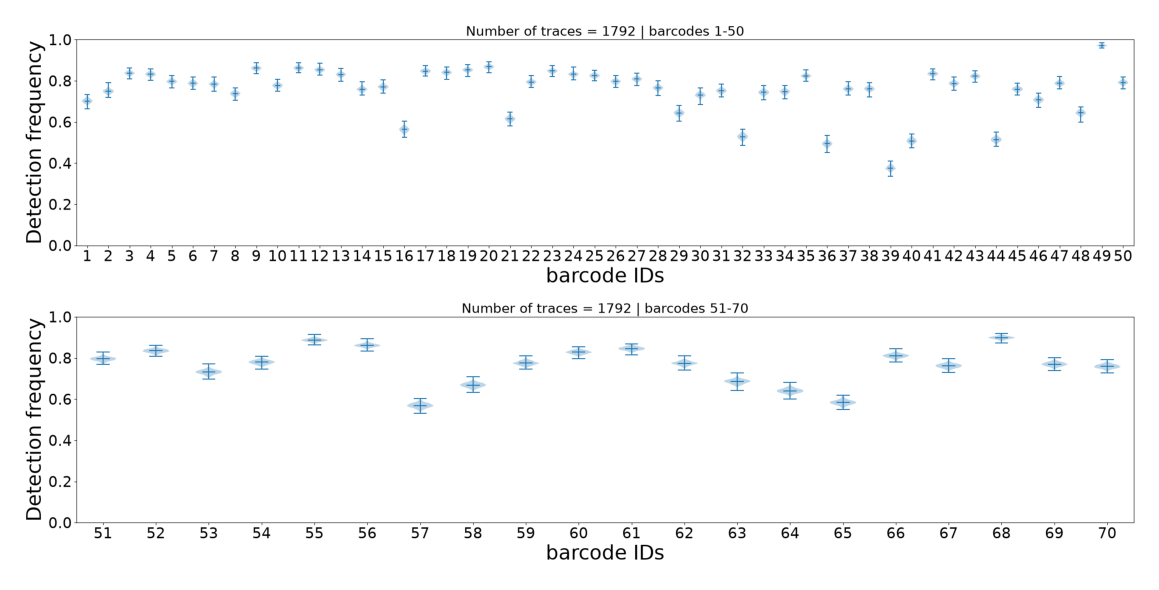

In [4]:
plot_file = f"{dest_path}/merged_traces_barcode_detection.png"
img = mpimg.imread(plot_file)
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()


This plot shows how often each individual barcode is detected across all traces. Each barcode is represented by a **violin plot** (bootstrap distribution with 1000 iterations), which shows:

- **Height of the violin**: Range of detection frequencies (0-100%)
- **Median line**: Most common detection frequency
- **Shape**: Distribution shape indicates consistency

**Interpretation:**
- Narrow violin = reliable barcode (consistent detection)
- Wide violin = unreliable barcode (variable detection)
- Barcodes with very low median detection may be candidates for `--remove_barcode` in Tutorial 3

## Step 3: Neighbor Distance Distribution

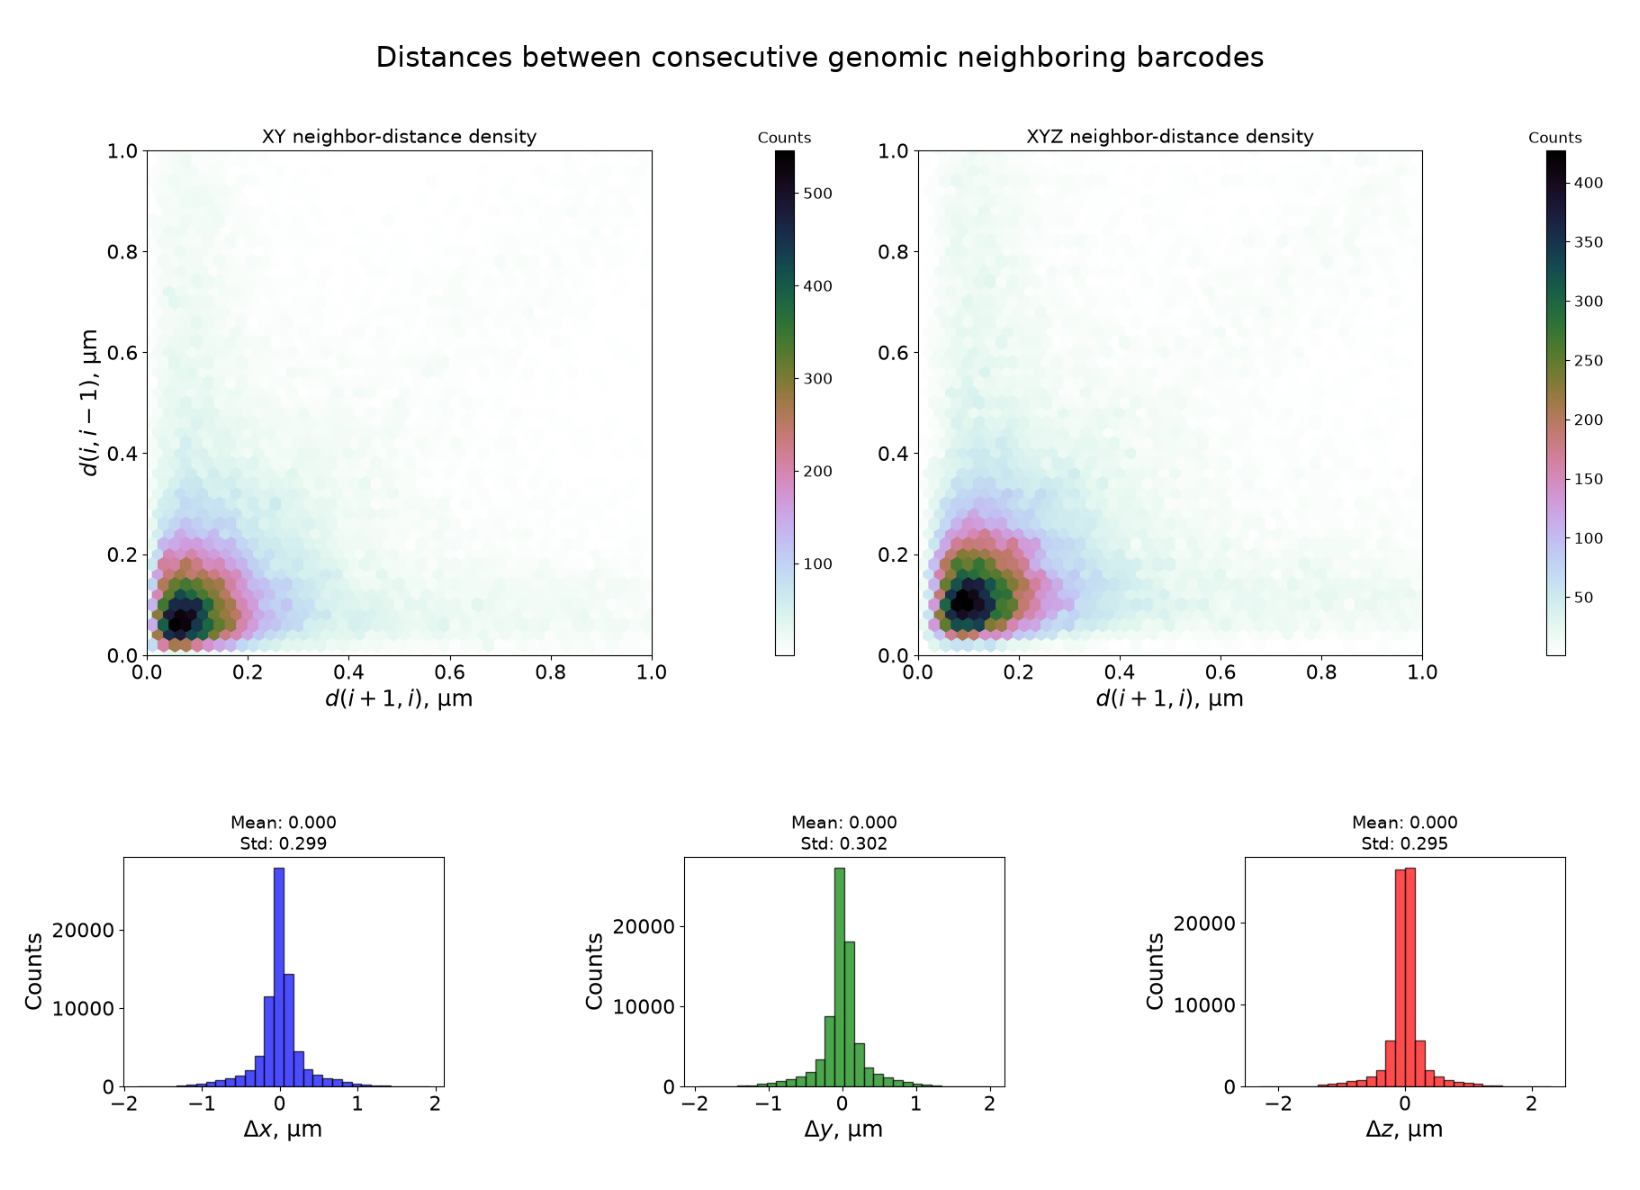

In [5]:
plot_file = f"{dest_path}/merged_traces_first_neighbor_distances.png"
img = mpimg.imread(plot_file)
fig, ax = plt.subplots(figsize=(20, 12))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

The top plot shows the density of neighbours between **consecutive distances** d(i, i-1 μm) for all traces. 

**Interpretation:**
- Density concentratated under 200 nm => this is reasonable for sequential barcodes
- Vertical, horizontal and diagonal light smear => likely some artefacts present

  
The bottom plot shows distances between **consecutive barcodes** (barcode_i+1 - barcode_i) for all traces. Three distributions are shown:

- **ΔX (blue)**: Distance in X dimension
- **ΔY (green)**: Distance in Y dimension
- **ΔZ (red)**: Distance in Z dimension (optical axis)

**Interpretation:**
- Bell-shaped, centered near 0 = uniform spacing between barcodes (expected)
- Large spread or multiple peaks = inconsistent spacing or detection issues
- ΔZ much larger than ΔX/ΔY = potential focusing problems

## Step 4: Barcode Repetition Patterns

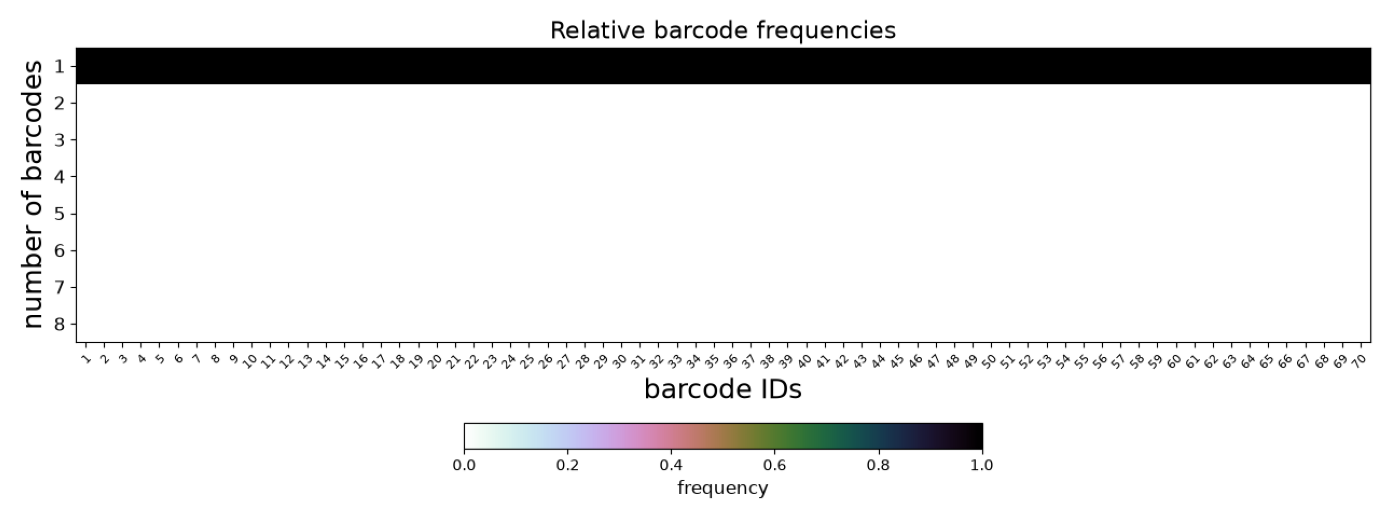

In [5]:
plot_file = f"{dest_path}/merged_traces_relative_barcode_frequencies.png"
img = mpimg.imread(plot_file)
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

This plot shows how often individual barcodes are **repeated** within single traces:

- **Y-axis**: Number of times each barcode appears per trace (repetition count)
- Near 1 = barcode appears once per trace (ideal)
- Toward 2+ = barcode frequently duplicated (optical artifacts or detection noise)

Duplicated barcodes are handled in Tutorial 4 (`--clean_spots`).

## Step 5: Trace Statistics Summary

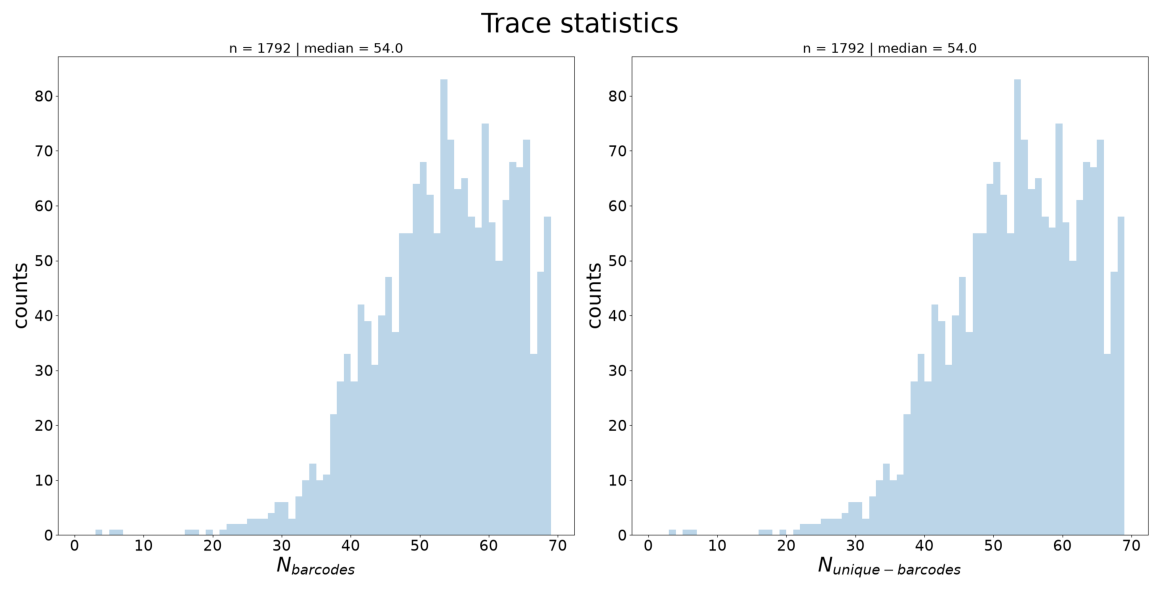

In [6]:
plot_file = f"{dest_path}/merged_traces_trace_statistics.png"
img = mpimg.imread(plot_file)
fig, ax = plt.subplots(figsize=(16, 6))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

Three distributions across all traces:

- **N_barcodes** (left): Number of barcode detections per trace
- **N_unique_barcodes** (middle): Number of distinct barcodes per trace


**Interpretation:**
- N_barcodes median indicates trace completeness → guides `--n_barcodes` threshold in Tutorial 3

## Step 6: Spatial Distribution (KDE Projections)

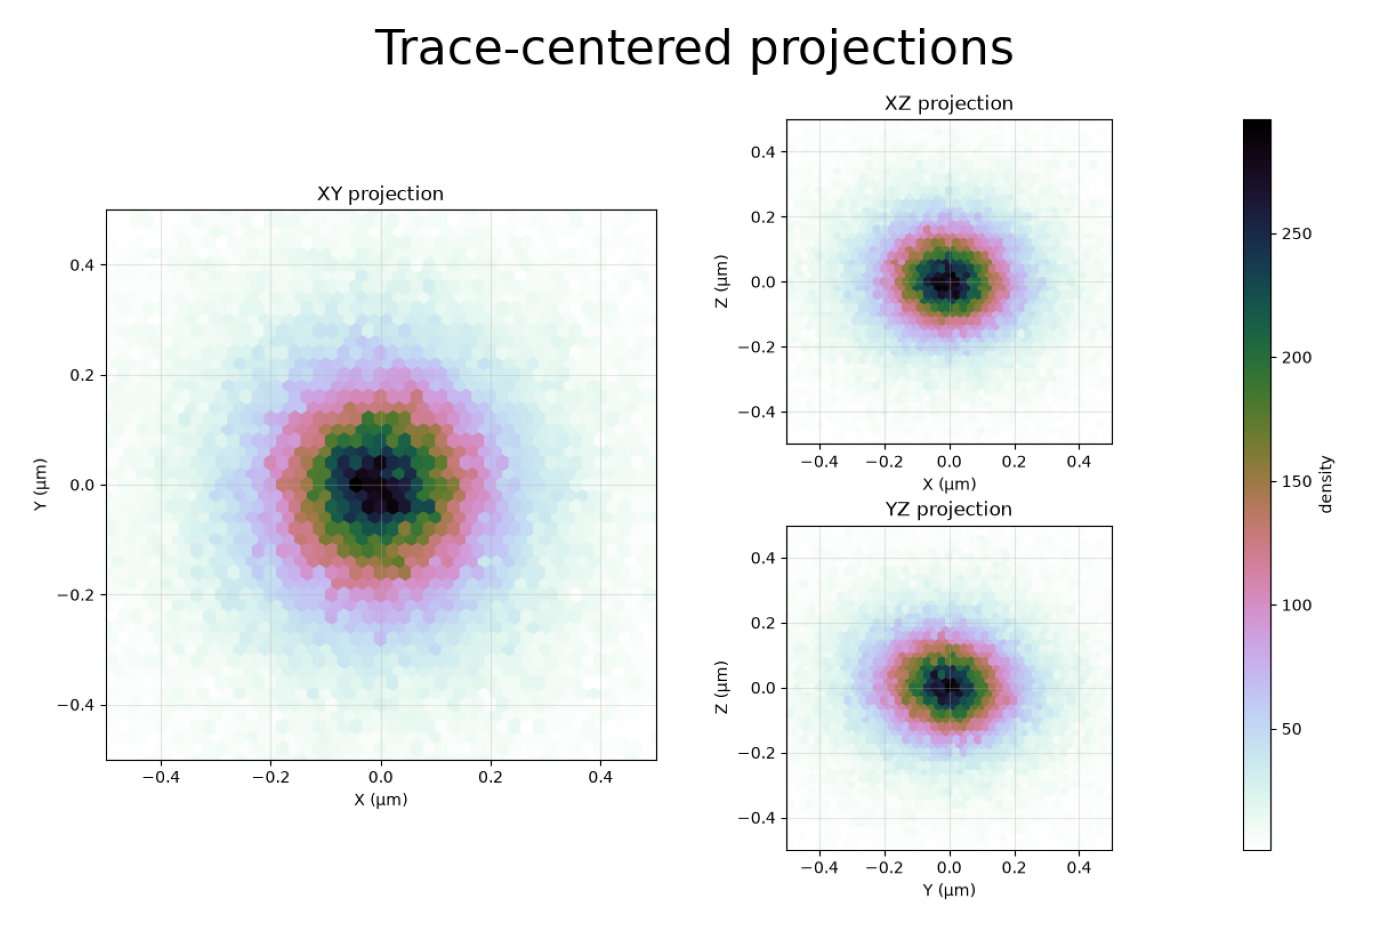

In [7]:
plot_file = f"{dest_path}/merged_traces_kde_projections.png"
img = mpimg.imread(plot_file)
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

#### This figure shows **kernel density estimation (KDE)** heatmaps of all spot positions projected onto three planes.
Before projection, all spot coordinates were translated so that their center of gravity (centroid) coincides with the origin !

- **XY projection** (left):  Top-down view of the sample. Darker regions indicate higher spot density.
- **XZ projection** (top-right): Side view along Y. Shows the Z range where spots are concentrated. 
- **YZ projection** (bottom-right): Side view along X.

**How this helps for filtering:**
- The **XZ** and **YZ** panels reveal the shape and symmetry of the distribution, providing information about spot quality and focus. Spots that are symmetrically distributed around the center indicate consistent localization, while asymmetric extensions or density far from the central region may indicate imaging artefacts or out-of-focus detections.
- If the **XY** panel shows spots concentrated in a sub-region, you could use
  `--x_min` / `--x_max` / `--y_min` / `--y_max` to exclude border artifacts.
- A uniform XY distribution is normal; clusters may indicate imaging artifacts or biological structure.

## Step 7: Using QC Insights for Filtering

From the QC plots above, you can extract key metrics to guide filtering in Tutorial 3:

| Plot | What to Look For | Filter Option |
|------|------------------|---------------|
| Barcode Detection | Barcodes with very low median | `--remove_barcode` |
| Trace Statistics | N_barcodes median | `--n_barcodes` |
| KDE Projections | Z range with spot concentration | `--z_min` / `--z_max` |
| KDE Projections | XY border artifacts | `--x_min` / `--y_max` etc. |

## Summary

Quality control revealed important characteristics of your merged dataset:

- **Trace completeness** — How many barcodes detected per trace
- **Barcode reliability** — Detection consistency for each barcode
- **Spatial distribution** — Where spots concentrate in X, Y, Z (KDE projections)
- **Neighbor spacing** — Distance characteristics (ΔX, ΔY, ΔZ)
- **Duplicate barcodes** — Repetition patterns across traces

**Next:** [Tutorial — Filter Traces](tutorial_filter_thresholds_traces.ipynb) using insights from these QC metrics